In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def averaging_blur(img: np.ndarray, kernel_size: int = 5) -> np.ndarray:
    """
    Apply averaging (mean) blur to a color image using a manual convolution.

    Parameters:
        img (np.ndarray): Input color image (BGR format).
        kernel_size (int): Size of the averaging kernel (must be odd).

    Returns:
        np.ndarray: Blurred color image.
    """

    # Ensure kernel size is odd
    if kernel_size % 2 == 0:
        raise ValueError("kernel_size must be an odd number.")

    # Create normalized averaging kernel
    kernel = np.ones((kernel_size, kernel_size), dtype=np.float32) / (kernel_size * kernel_size)

    # Get image dimensions
    if len(img.shape) != 3 or img.shape[2] != 3:
        raise ValueError("Input image must be a color image with 3 channels.")
    rows, cols, channels = img.shape

    # Border padding to handle edges
    k = kernel_size // 2
    padded = cv.copyMakeBorder(img, k, k, k, k, borderType=cv.BORDER_REPLICATE)

    # Create output image
    blurred_img = np.zeros_like(img, dtype=np.float32)

    # Perform convolution for each color channel
    for c in range(channels):
        for i in range(rows):
            for j in range(cols):
                # Extract the region of interest (window)
                window = padded[i:i+kernel_size, j:j+kernel_size, c]
                # Apply kernel (mean filter)
                blurred_img[i, j, c] = np.sum(window * kernel)

    # Clip values and convert to uint8
    blurred_img = np.clip(blurred_img, 0, 255).astype(np.uint8)
    return blurred_img

def gaussian_kernel(kernel_size: int, sigma: float) -> np.ndarray:
    """
    Generate a 2D Gaussian kernel.
    """
    k = kernel_size // 2
    x, y = np.mgrid[-k:k+1, -k:k+1]
    kernel = np.exp(-(x**2 + y**2) / (2 * sigma**2))
    kernel = kernel / (2 * np.pi * sigma**2)
    kernel /= np.sum(kernel)  # Normalize
    return kernel

    
def gaussian_blur(img: np.ndarray, kernel_size: int = 5, sigma: float = 1.0) -> np.ndarray:
    # Ensure kernel size is odd
    if kernel_size % 2 == 0:
        raise ValueError("kernel_size must be an odd number.")

    # Create a normalized averaging kernel
    kernel = gaussian_kernel(kernel_size, sigma)

    # Compute border size for padding
    pad_size = kernel_size // 2

    # Add border to handle edges (replicate border pixels)
    padded = cv.copyMakeBorder(img, pad_size, pad_size, pad_size, pad_size, borderType=cv.BORDER_REPLICATE)

    # Create an output image
    blurred_img = np.zeros_like(img, dtype=np.float32)

    rows, cols, channels = img.shape

    # Perform convolution manually
    for c in range(channels):
        for i in range(rows):
            for j in range(cols):
                window = padded[i:i+kernel_size, j:j+kernel_size, c]
                blurred_img[i, j, c] = np.sum(window * kernel)

    # Clip values and convert back to uint8
    blurred_img = np.clip(blurred_img, 0, 255).astype(np.uint8)

    return blurred_img


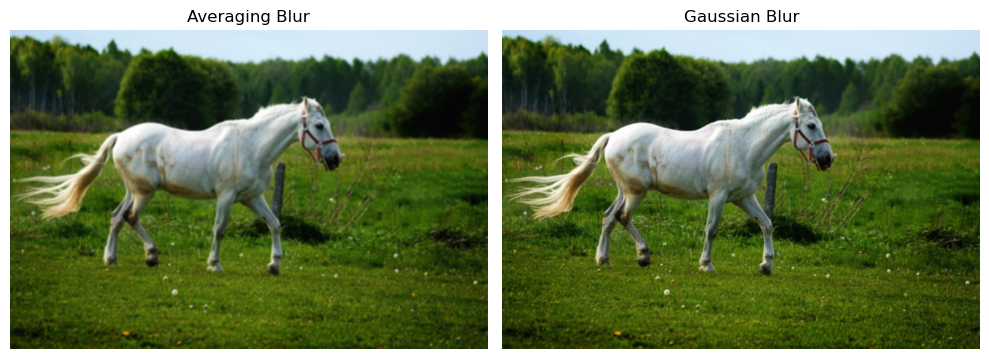

In [3]:
if __name__ == '__main__':
    
# --- Read input image ---
    path_image = r"C:\Users\COMPUTER WORLD\Desktop/23u03121_23u03086/DIPproject/L1/input.jpg"
    img = cv.imread(path_image)
    

    averaging_blured_img = averaging_blur(img)
    gaussian_blured_img = gaussian_blur(img)
    
    
    plt.figure(figsize=(10,5))
    
    plt.subplot(1, 2, 1)
    plt.imshow(cv.cvtColor(averaging_blured_img, cv.COLOR_BGR2RGB))
    plt.title('Averaging Blur')
    plt.axis('off')
    

    plt.subplot(1, 2, 2)
    plt.imshow(cv.cvtColor(gaussian_blured_img, cv.COLOR_BGR2RGB), cmap='gray')
    plt.title('Gaussian Blur')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()


    
    